## Plot distances

In [1]:
import pathlib

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('results/comparations_fc.csv', sep=',')
df

,img1,img2,dist,label
0,Anushka Sharma/Anushka Sharma_61.jpg,Anushka Sharma/Anushka Sharma_33.jpg,8.95,True
1,Anushka Sharma/Anushka Sharma_61.jpg,Anushka Sharma/Anushka Sharma_35.jpg,9.77,True
2,Anushka Sharma/Anushka Sharma_61.jpg,Anushka Sharma/Anushka Sharma_38.jpg,9.60,True
3,Anushka Sharma/Anushka Sharma_61.jpg,Anushka Sharma/Anushka Sharma_9.jpg,11.07,True
4,Anushka Sharma/Anushka Sharma_61.jpg,Anushka Sharma/Anushka Sharma_17.jpg,10.28,True
...,...,...,...,...
35215,Natalie Portman/Natalie Portman_20.jpg,Courtney Cox/Courtney Cox_43.jpg,10.48,False
35216,Natalie Portman/Natalie Portman_20.jpg,Courtney Cox/Courtney Cox_6.jpg,11.40,False
35217,Natalie Portman/Natalie Portman_65.jpg,Marmik/Marmik_19.jpg,15.70,False
35218,Natalie Portman/Natalie Portman_65.jpg,Anushka Sharma/Anushka Sharma_52.jpg,11.92,False


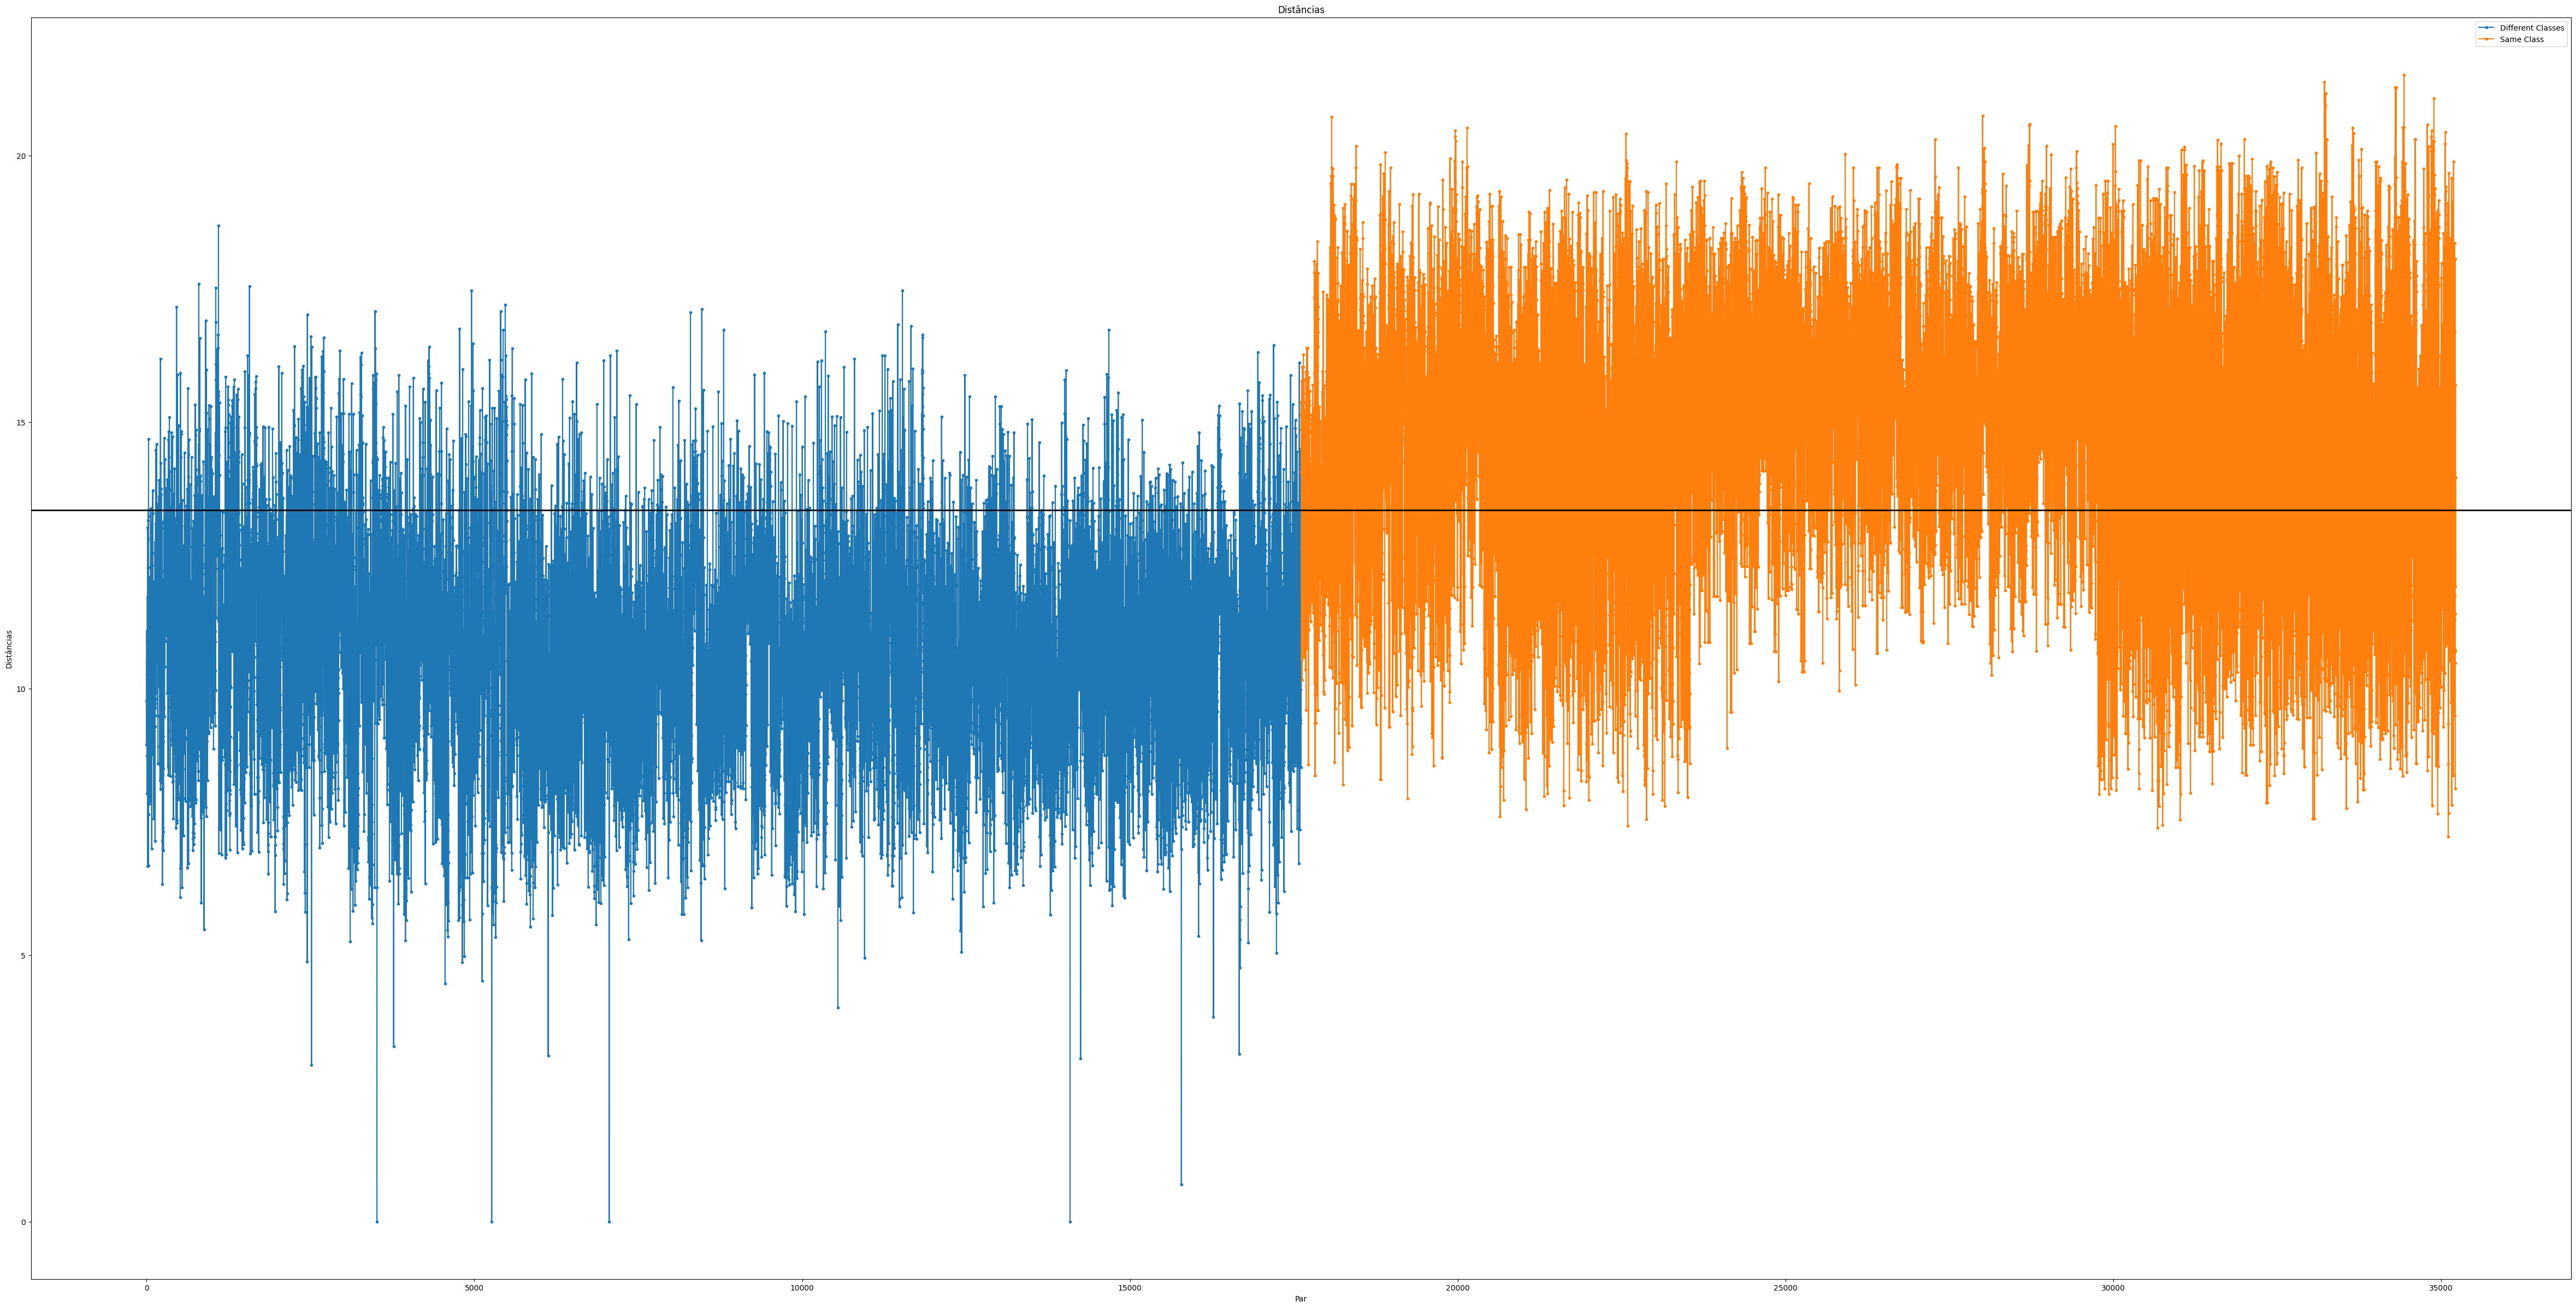

In [3]:
THRESHOLD = 13.351335667833917

plt.figure(figsize=(60, 30))

marker_size = 3

plt.plot(df[df['label']==True]['dist'], label='Different Classes', marker='o', markersize=marker_size)
plt.plot(df[df['label']==False]['dist'], label='Same Class', marker='o', markersize=marker_size)
plt.axhline(y=THRESHOLD,linewidth=2, color='k')

# Adding labels and title
plt.xlabel('Par')
plt.ylabel('Distâncias')
plt.title('Distâncias')

# Adding legend
plt.legend()

# Display and save the plot
pathlib.Path('results').mkdir(parents=True, exist_ok=True)
plt.savefig('results/distances.png')

## Move FN and FP to a folder to analyse

In [4]:
import shutil
import pathlib

In [5]:
THRESHOLD = 13.351335667833917

In [6]:
dataset_path = 'dataset/face-recognition-dataset/test'
output_path = 'results/wrongs/FN'
counter = 0
for row in df[(df['label']==True) & (df['dist']>THRESHOLD)].iterrows():
    folder = f'{row[1]['img1'][:row[1]['img1'].rfind("/")]}-{row[1]['img2'][:row[1]['img2'].rfind("/")]}'
    filename1 = row[1]['img1'][row[1]['img1'].rfind("/")+1:]
    filename2 = row[1]['img2'][row[1]['img2'].rfind("/")+1:]
    pathlib.Path(f'{output_path}/{folder}/{counter}-{row[1]['dist']}').mkdir(parents=True, exist_ok=True)
    shutil.copy(f'{dataset_path}/{row[1]['img1']}', f'{output_path}/{folder}/{counter}-{row[1]['dist']}/{filename1}')
    shutil.copy(f'{dataset_path}/{row[1]['img2']}', f'{output_path}/{folder}/{counter}-{row[1]['dist']}/{filename2}')
    counter += 1

In [7]:
dataset_path = 'dataset/face-recognition-dataset/test'
output_path = 'results/wrongs/FP'
counter = 0
for row in df[(df['label']==False) & (df['dist']<=THRESHOLD)].iterrows():
    folder = f'{row[1]['img1'][:row[1]['img1'].rfind("/")]}-{row[1]['img2'][:row[1]['img2'].rfind("/")]}'
    filename1 = row[1]['img1'][row[1]['img1'].rfind("/")+1:]
    filename2 = row[1]['img2'][row[1]['img2'].rfind("/")+1:]
    pathlib.Path(f'{output_path}/{folder}/{counter}-{row[1]['dist']}').mkdir(parents=True, exist_ok=True)
    shutil.copy(f'{dataset_path}/{row[1]['img1']}', f'{output_path}/{folder}/{counter}-{row[1]['dist']}/{filename1}')
    shutil.copy(f'{dataset_path}/{row[1]['img2']}', f'{output_path}/{folder}/{counter}-{row[1]['dist']}/{filename2}')
    counter += 1

## Change model threshold

In [ ]:
import json

import torch

import warnings
warnings.filterwarnings("ignore")

In [ ]:
PATH_MODEL = 'checkpoints/20250116-120128/best_45.pth'
THRESHOLD = 10

checkpoint = torch.load(PATH_MODEL)
checkpoint['threshold'] = THRESHOLD
torch.save(checkpoint, PATH_MODEL)

with open(PATH_MODEL.replace('.pth', '_results.json'), 'r+') as file:
    file_json = json.load(file)
    file_json['threshold'] = THRESHOLD
    file.seek(0)
    json.dump(file_json, file, indent=4)